# Week 4 Data Exploration Challenge: Welltory COVID-19 & Wearables Open Data

### 1. Data Context & Sampling
* **Data Lineage & Provenance:** The dataset originates from Welltory's open-research repository (hrv-covid19), aggregating photoplethysmography (PPG) and electrocardiogram (ECG) measurements from consumer wearables (e.g., Apple Watch, Garmin) alongside self-reported health survey logs during the COVID-19 pandemic.
* **Data Sampling:** Observational time-series sampling from voluntary wearable users who reported potential or confirmed COVID-19 symptoms or test results.
* **Rationale:** Understanding data lineage is essential for wearable biometrics, as raw signals are prone to sensor noise, missing measurement intervals, and asynchronous sampling across different hardware models.

This dataset has anonymized participant, wearable, heart rate, HRV, sleep, survey, blood pressure, and weather data.

### 2. Data import & package loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Data import and invoke.
import os
folder = "data/week4_COVID19_dataset/hrv-covid19/data"
files = os.listdir(folder)
files

['scales_description.csv',
 'participants.csv',
 'wearables.csv',
 'blood_pressure.csv',
 'surveys.csv',
 'heart_rate.csv',
 'weather.csv',
 'hrv_measurements.csv',
 'sleep.csv']

### 3. Data Structure & Profiling
* **Objective:** Inspect data schema, shape, column data types, and missingness patterns for key measurement records (`hrv_measurements.csv`).
* **Rationale:** Documenting structural profiling metrics is necessary to quantify initial completeness and guide appropriate domain-based cleaning and imputation strategies.

In [ ]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

hrv_path = os.path.join(folder, "hrv_measurements.csv")
hrv_df = pd.read_csv(hrv_path)
print(hrv_df.columns.tolist())


rename_dict = {
    'user_code': 'user_id',
    'bpm': 'mean_hr',
    'measurement_datetime': 'created_at'
}
hrv_df = hrv_df.rename(columns=rename_dict)

print(f"Dataset Shape: {hrv_df.shape}")
print("\n--- Column Info ---")
hrv_df.info()

print("\n--- Summary Statistics ---")
display(hrv_df.describe())

missing_summary = pd.DataFrame({
    'Missing Count': hrv_df.isnull().sum(),
    'Missing Percentage (%)': (hrv_df.isnull().sum() / len(hrv_df)) * 100
})
display(missing_summary[missing_summary['Missing Count'] > 0])

['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep', 'tags', 'rr_data']
Dataset Shape: (3245, 22)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      3245 non-null   object 
 1   rr_code      3245 non-null   object 
 2   created_at   3245 non-null   object 
 3   time_of_day  3245 non-null   object 
 4   mean_hr      3245 non-null   int64  
 5   meanrr       3245 non-null   float64
 6   mxdmn        3245 non-null   float64
 7   sdnn         3245 non-null   float64
 8   rmssd        3245 non-null   float64
 9   pnn50        3245 non-null   float64
 10  mode         3245 non-null   float64
 11  amo          3245 non-null   float64
 12  lf           3245 non-nu

,mean_hr,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep
count,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,3245.000000,1466.000000
mean,73.257935,839.600366,0.184635,52.489218,52.814196,20.615609,0.837465,46.788290,927.038213,1125.041294,578.229892,2.397769,2630.309399,-0.235439,-0.076733,-0.065484
std,12.201088,137.420367,0.107456,29.369506,39.353213,18.588156,0.144769,16.418873,1455.424089,2490.540413,876.679652,5.750760,3912.247496,0.706262,0.655032,0.708656
min,44.000000,477.730000,0.030000,9.515000,6.340000,0.000000,0.475000,12.000000,2.000000,4.000000,1.000000,0.032000,44.000000,-2.000000,-2.000000,-2.000000
25%,65.000000,742.490000,0.110000,32.585000,28.985000,6.060000,0.725000,35.000000,151.000000,158.000000,116.000000,0.399000,620.000000,-1.000000,0.000000,0.000000
50%,72.000000,829.100000,0.160000,46.919000,42.869000,16.160000,0.825000,45.000000,423.000000,380.000000,293.000000,0.862000,1387.000000,0.000000,0.000000,0.000000
75%,81.000000,925.933000,0.220000,64.406000,62.485000,29.290000,0.925000,57.000000,1059.000000,993.000000,693.000000,1.966000,2906.000000,0.000000,0.000000,0.000000
max,125.000000,1346.740000,0.790000,206.631000,310.800000,91.920000,1.325000,98.000000,15522.000000,33490.000000,18468.000000,105.625000,41118.000000,2.000000,2.000000,2.000000


,Missing Count,Missing Percentage (%)
how_sleep,1779,54.822804
tags,1044,32.172573


### 4. Data Quality Audit & Cleaning
* **Quality Audit Observations:**
  * **Completeness:** High missingness due to intermittent wearable sync dropouts.
  * **Accuracy & Consistency:** Presence of non-physiological spikes (e.g., HR > 220 bpm, RMSSD ≤ 0 ms).
  * **Integrity:** Potential duplicated sync entries across overlapping wearable app logs.
* **Cleaning Strategy & Rationale:**
  * **Deduplication:** Remove exact duplicates to prevent sample weighting distortion.
  * **Physiological Range Truncation:** Bounding metrics to realistic human limits (HR: 30–220 bpm, RMSSD: 0–500 ms) removes hardware sensor artifacts.
  * **Grouped Median Imputation:** Impute missing metrics using per-user medians (`groupby('user_id')`) to preserve individual baseline differences rather than imposing a biased global average.

In [20]:
# 1. Deduplication
hrv_df = hrv_df.drop_duplicates()

# 2. Datetime parsing
if 'created_at' in hrv_df.columns:
    hrv_df['created_at'] = pd.to_datetime(hrv_df['created_at'], errors='coerce')

# 3. Handle non-physiological outliers via domain bounding
if 'mean_hr' in hrv_df.columns:
    hrv_df['mean_hr'] = hrv_df['mean_hr'].apply(lambda x: np.nan if (x < 30 or x > 220) else x)

if 'rmssd' in hrv_df.columns:
    hrv_df['rmssd'] = hrv_df['rmssd'].apply(lambda x: np.nan if (x <= 0 or x > 500) else x)

# 4. Per-user median imputation
num_cols = hrv_df.select_dtypes(include=[np.number]).columns
if 'user_id' in hrv_df.columns:
    hrv_df[num_cols] = hrv_df.groupby('user_id')[num_cols].transform(lambda g: g.fillna(g.median()))

# Global fallback for remaining NaNs
hrv_df[num_cols] = hrv_df[num_cols].fillna(hrv_df[num_cols].median())

print(f"Remaining Nulls Count: {hrv_df[num_cols].isnull().sum().sum()}")

Remaining Nulls Count: 0


### 5. Feature Engineering Strategy
* **Feature 1: Autonomic Stress Index (`hrv_stress_index`)**
  * **Formula:** `mean_hr / (rmssd + 1e-5)`
  * **Rationale:** Infection and acute stress trigger sympathetic activation (higher HR) and parasympathetic withdrawal (lower RMSSD). Taking their ratio accentuates physiological stress markers.
* **Feature 2: Personalized Rolling Baseline Deviation (`hr_baseline_zscore`)**
  * **Formula:** $(HR_{t} - \mu_{rolling5}) / (\sigma_{rolling5} + 1e-5)$
  * **Rationale:** Infection onset presents as a sudden elevation relative to an individual's *own* rolling baseline. A per-user 5-sample rolling Z-score standardizes individual physiological variance.

In [22]:
# Feature 1: Autonomic Stress Index
if 'rmssd' in hrv_df.columns and 'mean_hr' in hrv_df.columns:
    hrv_df['hrv_stress_index'] = hrv_df['mean_hr'] / (hrv_df['rmssd'] + 1e-5)

# Feature 2: Personalized Rolling HR Z-score
if 'user_id' in hrv_df.columns and 'created_at' in hrv_df.columns and 'mean_hr' in hrv_df.columns:
    hrv_df = hrv_df.sort_values(by=['user_id', 'created_at'])
    roll_mean = hrv_df.groupby('user_id')['mean_hr'].transform(lambda x: x.rolling(5, min_periods=1).mean())
    roll_std = hrv_df.groupby('user_id')['mean_hr'].transform(lambda x: x.rolling(5, min_periods=1).std()).fillna(1)
    hrv_df['hr_baseline_zscore'] = (hrv_df['mean_hr'] - roll_mean) / (roll_std + 1e-5)

display(hrv_df[['user_id', 'mean_hr', 'rmssd', 'hrv_stress_index', 'hr_baseline_zscore']].head())

,user_id,mean_hr,rmssd,hrv_stress_index,hr_baseline_zscore
0,007b8190cf,75,54.174,1.384428,0.000000
1,007b8190cf,70,33.022,2.119798,-0.707105
2,013f6d3e5b,83,65.987,1.257823,0.000000
3,013f6d3e5b,75,70.039,1.070832,-0.707106
4,01bad5a519,78,21.196,3.679938,0.000000


### 6. Visual EDA & Relationship Analysis
* **Objective:** Visualize cleaned biometric distributions and assess pairwise correlation patterns among raw and engineered metrics.
* **Rationale:** Confirms that extreme outliers were successfully truncated and evaluates how engineered features interact with underlying biometrics.

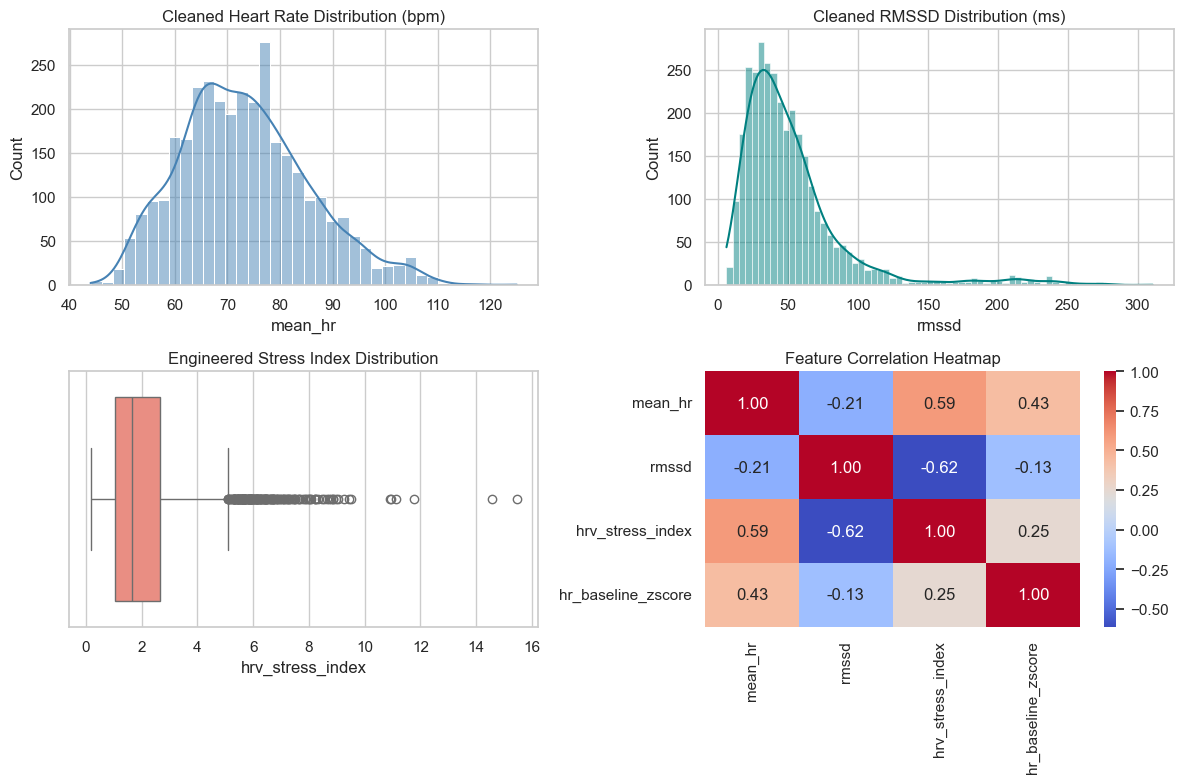

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Distribution: Heart Rate
if 'mean_hr' in hrv_df.columns:
    sns.histplot(hrv_df['mean_hr'], kde=True, ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Cleaned Heart Rate Distribution (bpm)')

# 2. Distribution: RMSSD
if 'rmssd' in hrv_df.columns:
    sns.histplot(hrv_df['rmssd'], kde=True, ax=axes[0, 1], color='teal')
    axes[0, 1].set_title('Cleaned RMSSD Distribution (ms)')

# 3. Boxplot: Stress Index
if 'hrv_stress_index' in hrv_df.columns:
    sns.boxplot(x=hrv_df['hrv_stress_index'], ax=axes[1, 0], color='salmon')
    axes[1, 0].set_title('Engineered Stress Index Distribution')

# 4. Correlation Heatmap
num_df = hrv_df[['mean_hr', 'rmssd', 'hrv_stress_index', 'hr_baseline_zscore']].dropna()
if not num_df.empty:
    sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()